In [1]:
# ==============================
# 1️⃣  بارگذاری پکیج‌ها
# ==============================
import pandas as pd
import numpy as np
import scipy.stats as stats
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns



Before cleaning: 23079 trials
After cleaning:  22649 trials

Sample of aggregated data:
   caseid  Block   congruency  mean_RT_ms
0       1      3    congruent  775.425957
1       1      3  incongruent  842.549479
2       1      6    congruent  914.450695
3       1      6  incongruent  947.349025
4       2      3    congruent  612.763908


C:\Users\hosse\AppData\Local\Temp\ipykernel_13492\3717389002.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cleaned = data.groupby('caseid', group_keys=False).apply(trim_within_subject)


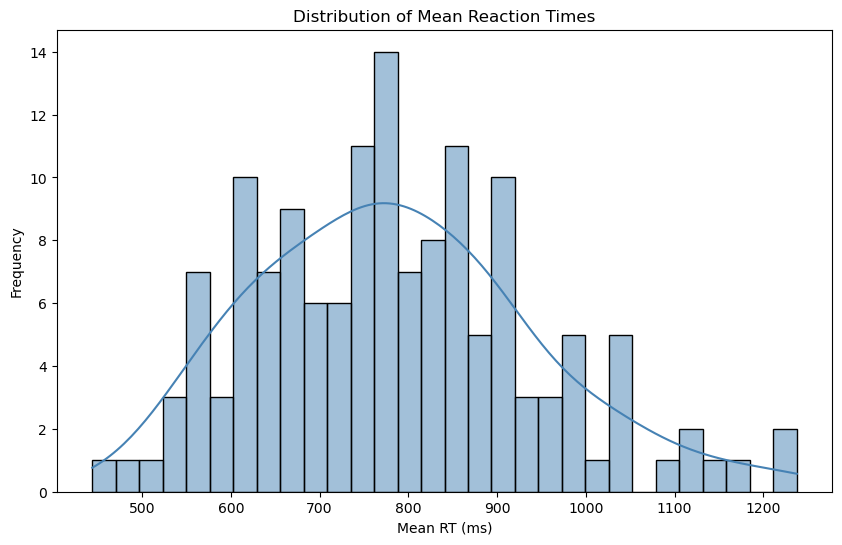

c:\Users\hosse\miniconda3\envs\ML\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\hosse\miniconda3\envs\ML\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
c:\Users\hosse\miniconda3\envs\ML\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\hosse\miniconda3\envs\ML\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1


Shapiro–Wilk Test for Normality:
ShapiroResult(statistic=np.float64(0.9818808604239815), pvalue=np.float64(0.05389026833564838))

Mauchly’s Test of Sphericity:
(True, nan, nan, 1, 1.0)

Repeated-Measures ANOVA Results:
               Source             SS  ddof1  ddof2             MS           F  \
0               Block  690439.388206      1     35  690439.388206  151.092100   
1          congruency    6348.925792      1     35    6348.925792    8.717845   
2  Block * congruency   24594.000858      1     35   24594.000858   25.600742   

          p-unc     p-GG-corr       ng2  eps  
0  2.953379e-14  2.953379e-14  0.196084  1.0  
1  5.596159e-03  5.596159e-03  0.002238  1.0  
2  1.339374e-05  1.339374e-05  0.008613  1.0  

Post-hoc Pairwise Comparisons (Bonferroni corrected):
             Contrast Block          A            B Paired Parametric  \
0               Block     -          3            6   True       True   
1          congruency     -  congruent  incongruent   True       T

In [5]:
# ==========================================
# 2️⃣ Read the data
# ==========================================
data = pd.read_csv("main_data_filled.csv")

# Check required columns
required_cols = ['response_time', 'caseid', 'Block', 'congruency']
for col in required_cols:
    if col not in data.columns:
        raise ValueError(f"Missing required column: {col}")

# ==========================================
# 3️⃣ Preprocessing
# ==========================================
data['response_time_ms'] = data['response_time'] * 1000  # convert to ms
data = data[data['response_time_ms'] >= 200]  # remove anticipations (<200ms)

# Remove outliers per participant (±3 SD)
def trim_within_subject(df):
    m = df['response_time_ms'].mean()
    s = df['response_time_ms'].std()
    return df[(df['response_time_ms'] >= m - 3*s) & (df['response_time_ms'] <= m + 3*s)]

cleaned = data.groupby('caseid', group_keys=False).apply(trim_within_subject)

# Check how many trials were removed
print(f"Before cleaning: {len(data)} trials")
print(f"After cleaning:  {len(cleaned)} trials")

# ==========================================
# 4️⃣ Aggregate by participant × condition
# ==========================================
summary = cleaned.groupby(['caseid', 'Block', 'congruency'], as_index=False)['response_time_ms'].mean()
summary = summary.rename(columns={'response_time_ms': 'mean_RT_ms'})

print("\nSample of aggregated data:")
print(summary.head())

# ==========================================
# 5️⃣ Check normality (Shapiro–Wilk) + plot
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(summary['mean_RT_ms'], kde=True, bins=30, color='steelblue')
plt.title("Distribution of Mean Reaction Times")
plt.xlabel("Mean RT (ms)")
plt.ylabel("Frequency")
plt.show()

shapiro_res = stats.shapiro(summary['mean_RT_ms'])
print("\nShapiro–Wilk Test for Normality:")
print(shapiro_res)

# ==========================================
# 6️⃣ Check sphericity and homogeneity
# ==========================================
# Pivot data to wide format for Mauchly’s test
pivot_df = summary.pivot_table(index='caseid', columns=['Block', 'congruency'], values='mean_RT_ms')

# Mauchly’s test for sphericity (via Pingouin)
anova_data = summary.rename(columns={'caseid': 'Subject', 'mean_RT_ms': 'RT'})
mauchly = pg.sphericity(data=anova_data, dv='RT', subject='Subject', within=['Block', 'congruency'])
print("\nMauchly’s Test of Sphericity:")
print(mauchly)

# ==========================================
# 7️⃣ Run Repeated-Measures ANOVA
# ==========================================
anova = pg.rm_anova(dv='RT', within=['Block', 'congruency'], subject='Subject', 
                    data=anova_data, detailed=True)
print("\nRepeated-Measures ANOVA Results:")
print(anova)

# ==========================================
# 8️⃣ Post-hoc pairwise comparisons (Bonferroni)
# ==========================================
posthoc = pg.pairwise_tests(dv='RT', within=['Block', 'congruency'], subject='Subject',
                             data=anova_data, padjust='bonf')
print("\nPost-hoc Pairwise Comparisons (Bonferroni corrected):")
print(posthoc)

C:\Users\hosse\AppData\Local\Temp\ipykernel_13492\2183788315.py:5: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  sns.pointplot(data=summary, x='Block', y='mean_RT_ms', hue='congruency',


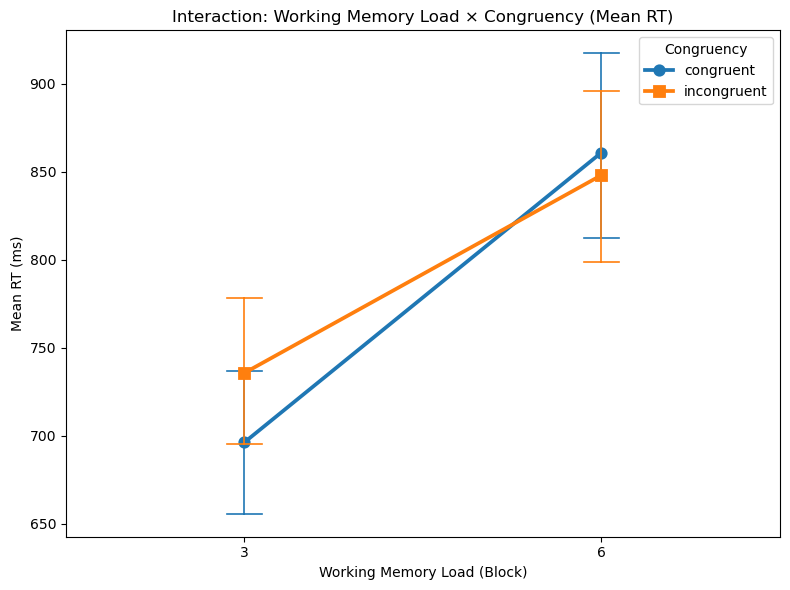

In [4]:
# ==========================================
# 9️⃣ Plot interaction
# ==========================================
plt.figure(figsize=(8,6))
sns.pointplot(data=summary, x='Block', y='mean_RT_ms', hue='congruency',
              markers=['o', 's'], capsize=.1, errwidth=1.2)
plt.title("Interaction: Working Memory Load × Congruency (Mean RT)")
plt.xlabel("Working Memory Load (Block)")
plt.ylabel("Mean RT (ms)")
plt.legend(title="Congruency")
plt.tight_layout()
plt.show()

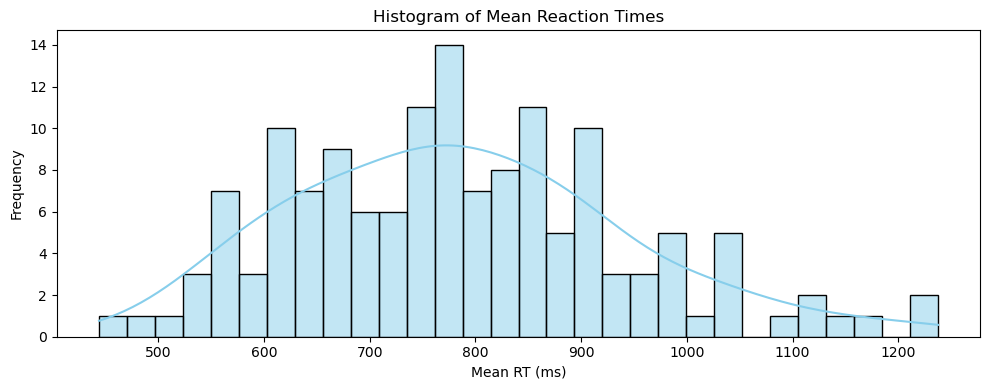

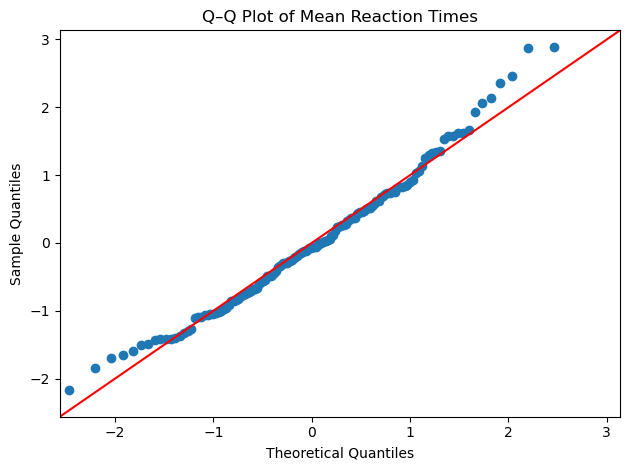

In [3]:
# ==========================================
# 🔍 10️⃣ Plot: Histogram + Q–Q plot of mean RTs
# ==========================================
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Histogram
plt.figure(figsize=(10, 4))
sns.histplot(summary['mean_RT_ms'], bins=30, kde=True, color='skyblue')
plt.title("Histogram of Mean Reaction Times")
plt.xlabel("Mean RT (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) Q–Q Plot
sm.qqplot(summary['mean_RT_ms'], line='45', fit=True)
plt.title("Q–Q Plot of Mean Reaction Times")
plt.tight_layout()
plt.show()
